# Supervised Learning Demo I: Regression


In this notebook, we will take our first steps into machine learning by training a simple model to predict housing prices using the California Housing dataset. 

Along the way, we will follow a typical machine learning workflow: exploring the data, splitting it into training and test sets, training a model, and evaluating its performance.

The goal is not only to build a model, but also to understand the key ideas behind each step and how they fit together in a complete machine learning pipeline.

>
> ℹ️ Info about this notebook:
>
> - Goal: intro to Machine Learning -focusing on the main steps to train an ML model
> - Dataset: California Housing Dataset
> - Models: Linear Regression + Polynomial Regression
> 



<br>

## 1. The Problem

For this demo, we will work with the **California Housing Dataset** — a classic dataset used in machine learning education.

**Goal:** Predict the **median house value** of a California district, given features like average income, house age, number of rooms, population, and geographic location.

This is a **regression** problem: our target variable is a continuous number (house price), not a category.

Worth to mention: We use the median rather than the mean because housing prices can contain extreme outliers; the median provides a more robust measure of a district's typical home value (because it is less sensitive to unusually expensive properties).



<br>

## 2. Load the Dataset

The California Housing Dataset is conveniently available in **scikit-learn** (`sklearn`) — the go-to Python library for classic Machine Learning. No file download needed.



In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()

# display(housing)

`fetch_california_housing()` returns a `Bunch` object (similar to a dictionary). We can access:
- `.data` — the feature matrix (inputs `X`)
- `.target` — the target values (output `y`)
- `.feature_names` — the names of the features

We'll wrap everything in a **pandas DataFrame** to make it easier to work with.


In [2]:
# Build a DataFrame with features + target
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target  # add the target column

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (20640, 9)


The dataset has **20,640 rows** (districts) and **9 columns** (8 features + 1 target).

Here's an explanation of each column:

| Feature | Description |
|---|---|
| `MedInc` | Median income in the district |
| `HouseAge` | Median house age in the district |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | District population |
| `AveOccup` | Average number of household members |
| `Latitude` | District latitude |
| `Longitude` | District longitude |
| **`MedHouseVal`** | **Target: Median house value (in $100,000s)** |


<br>

## 3. Exploratory Data Analysis (EDA)

Before training any model, we explore the data to understand its structure, spot any issues, and gain intuition about which features might be useful.


Let's check the data types and whether there are any missing values:


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
# Check for missing values
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

**No cleaning is needed here** — the California Housing dataset is already clean (no missing values, all numeric features).

### Summary Statistics

`df.describe()` gives us a quick statistical overview of every column: count, mean, standard deviation, min/max, and quartiles.


In [6]:
df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Target Variable Distribution

Let's look at the distribution of our target variable — the median house value.


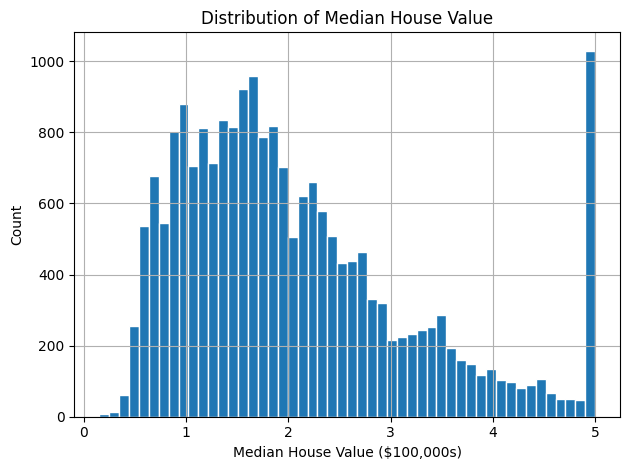

In [7]:
import matplotlib.pyplot as plt

df["MedHouseVal"].hist(bins=50, edgecolor="white")
plt.xlabel("Median House Value ($100,000s)")
plt.ylabel("Count")
plt.title("Distribution of Median House Value")
plt.tight_layout()
plt.show()


Notice the sharp spike at **5.0** — prices were capped at $500,000 in this dataset. This is a known quirk worth keeping in mind, but it won't stop us from building a useful model.


<br><hr><hr><br>

## Discover: Data Splitting

Before continuing, spend a few minutes researching:
1. What is data splitting in machine learning?
2. Why is it important to split the data before training a model?
3. What are the most common data splitting approaches (e.g., Train/Test split, Train/Validation/Test split, Cross-Validation)?

Bonus: 
- Implement a Train/Test split for this dataset using Scikit-learn and verify the number of observations in the training and testing sets.


Time: 12 minutes.

<br><hr><hr><br>


<br>

## 4. Data Splitting (Train / Test Split)

Before training a model, we need to split the data into two subsets:

- **Training set** — used to fit (train) the model.
- **Test set** — held out and used only to evaluate the model after training.

This separation is essential: if we evaluate on the same data we trained on, we get an overly optimistic picture of performance. The test set simulates unseen data — it tells us how well the model generalises.

![train-test-split](../_images/train-test-split.avif)

(Image Credit: Michael Galarnyk)

<br>

**First**, we separate the features (`X`) from the target (`y`):


In [8]:

# Separate features (X) from the target (y)
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (20640, 8)
y shape: (20640,)


<br>

Now, let's split into train and test sets. A common split is **80% train / 20% test**. 

Scikit-learn's `train_test_split` handles this in one line. `random_state` fixes the random seed so results are reproducible.

In [9]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Note: using a fixed value for "random_state" ensures that every time the code is run, the same observations will be assigned to the training and testing sets. This is useful if you need the same split every time (e.g., when you want to compare different models, for debugging, testing, teaching, etc.)

print("Training set size: ", X_train.shape[0])
print("Test set size:     ", X_test.shape[0])


Training set size:  16512
Test set size:      4128



<br>

## 5. Model Training: Linear Regression

**Linear Regression** is one of the simplest and most interpretable ML models. It assumes the target can be approximated as a weighted sum of the input features:

$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b$$

where:
- $x_1, \dots, x_n$ are the feature values
- $w_1, \dots, w_n$ are the **weights** (learned from data)
- $b$ is the **bias** (intercept)

<br>

![linear_regression-i](../_images/linear_regression-i.png)

(Image source: [medium](https://medium.com/nextgenllm/simple-linear-regression-the-complete-guide-with-theory-formulas-and-realworld-examples-7799b0bacd46))

<br>


Training means finding the weights and bias that minimise the prediction error on the training set.

In scikit-learn, training a supervised model always follows the same two-step pattern:

```python
model = ModelClass()   # 1. Create the model
model.fit(X_train, y_train)  # 2. Train it on the training data
```


In [10]:

from sklearn.linear_model import LinearRegression

# 1. Create the model
model = LinearRegression()

# 2. Train on the training set
model.fit(X_train, y_train)

print("Model trained!")


Model trained!


After training, we can inspect the learned coefficients — one weight per feature, plus an intercept:

In [11]:

coefficients = pd.Series(model.coef_, index=X.columns)
print("Intercept:", round(model.intercept_, 4))
print("\nFeature coefficients:")
print(coefficients.round(4))


Intercept: -37.0233

Feature coefficients:
MedInc        0.4487
HouseAge      0.0097
AveRooms     -0.1233
AveBedrms     0.7831
Population   -0.0000
AveOccup     -0.0035
Latitude     -0.4198
Longitude    -0.4337
dtype: float64



![linear_regression-ii](../_images/linear-regression-ii.png)

<br>

With one input variable, linear regression is a line; with two input variables, it's a plane in 3D space; with three or more, it's a hyperplane in higher-dimensional space. In all cases, the model represents a flat linear surface mapping multiple inputs to a single output.

![linear_regression-iii](../_images/linear-regression-iii.jpg)

(Image source: [MachineLearnAthon](https://www.youtube.com/watch?v=zJjOrB5xmRc))



<br>

## 6. Model Evaluation: R²

A trained model is only useful if it makes good predictions. We evaluate on the **test set** — data the model has never seen.

For this demo, we will use a metric called R² score.

<br>


### R² score


The **R² score** (R-squared), also called the coefficient of determination, is a metric used in regression to measure **how well a model explains the variability of the target variable**.

<br>

Definition:

R² tells you the proportion of variance in the dependent variable y that is explained by the independent variables in your model.


$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$


Where: 

$y_i = \text{true values}$  
$\hat{y}_i = \text{predicted values}$  
$\bar{y} = \text{mean of true values}$


<br>

| R² value | Meaning |
|---|---|
| 1.0 | Perfect predictions |
| 0.0 | Model does no better than predicting the mean |
| < 0.0 | Model performs worse than the mean |


Key idea:
- R² answers the question "How much of the variation in the data did my model successfully explain, compared to just using the mean?"




In [12]:
from sklearn.metrics import r2_score

y_test_pred = model.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)

print(f"R² (test set): {r2_test:.4f}")


R² (test set): 0.5758


**Interpreting the result:**

An R² of 0.58 means the model explains about 58% of the variance in house prices on unseen data using the available features in the California Housing dataset.

The remaining variance is due to a combination of factors not captured by the model, including missing explanatory variables, inherent noise in the data, and limitations of the linear modeling assumption.

For a simple linear model without feature engineering, this is a reasonable baseline performance. More complex models (e.g., polynomial regression, tree-based models) or richer feature engineering would typically improve R² further.


<br>

## 7. Training a Second Model: Polynomial Regression (deg=2)

Our linear model achieved R² ≈ 0.58 on the test set. Can we do better?

Linear regression assumes the relationship between features and the target is strictly linear. But real-world data often has **non-linear patterns** — for example, the effect of a feature may accelerate or interact with other features in ways a flat linear surface can't capture.

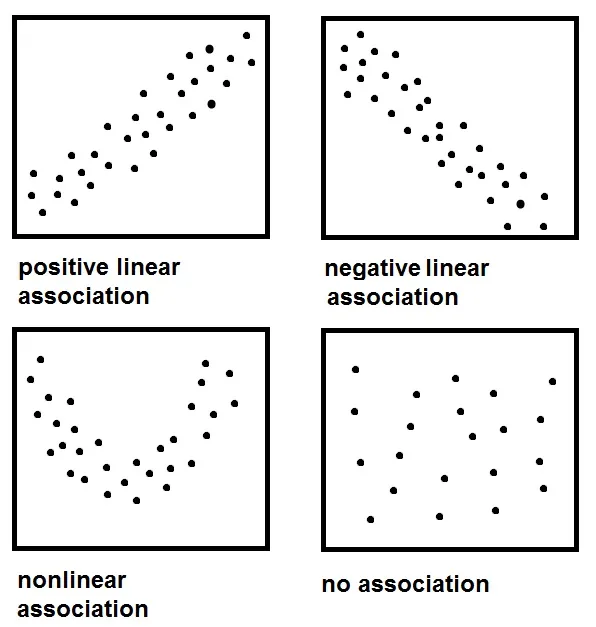

(Image source: [mathbootcamps](https://www.mathbootcamps.com/reading-scatterplots/))

<br>

Here are some examples of non-linear functions:

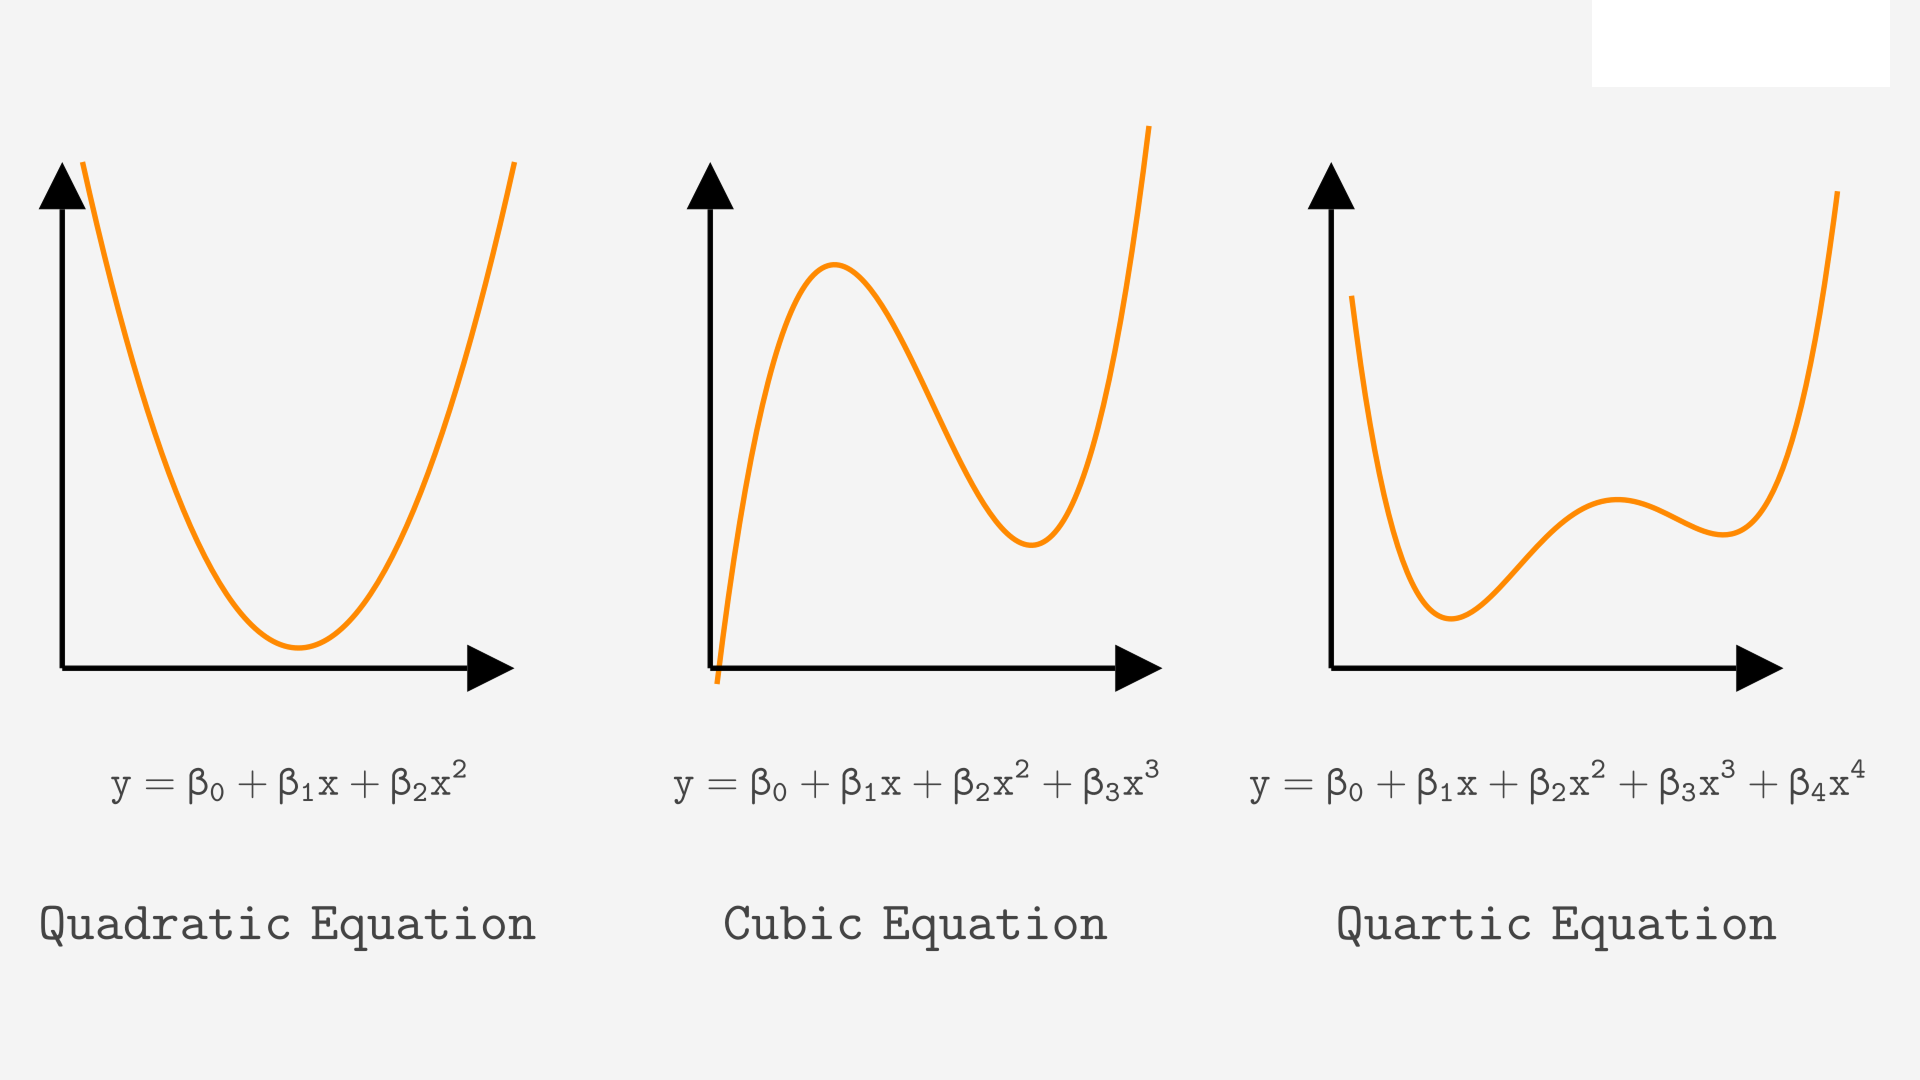

<br>

**Polynomial regression** extends linear regression by adding polynomial combinations of the original features (e.g. $x^2$, $x_1 \cdot x_2$) as additional inputs.

The model is still a `LinearRegression` under the hood — we're just feeding it richer features:

$$\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_1^2 + w_4 x_1 x_2 + w_5 x_2^2 + \cdots + b$$

<br>

![polynomial-regression-i](../_images/polynomial-regression-i.jpg)

<br>

![polynomial-regression-ii](../_images/polynomial-regression-ii.png)


<br>

### Training our Polynomial Regression model

Let’s train a polynomial regression model! 

For this demo, we will expand our original features to include additional terms such as squared values and interactions between features (for now, we will train our model on features up to the power 2, but not higher powers). 

Once we have created the features, we will fit a linear regression model on this expanded dataset and evaluate its performance.



In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Step 1: expand features to degree-2 polynomial combinations
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)   # fit on train, then transform
X_test_poly  = poly.transform(X_test)        # transform test using the same fitted poly

# Step 2: fit linear regression on the expanded features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

r2_test_poly  = poly_model.score(X_test_poly, y_test)

print(f"Linear Regression  — R² test: {r2_test:.4f}")
print(f"Polynomial (deg=2) — R² test: {r2_test_poly:.4f}")


Linear Regression  — R² test: 0.5758
Polynomial (deg=2) — R² test: 0.6457


<br>

Looking good! The performance of our polynomial regression model (degree = 2) has improved 💪

This naturally raises an interesting question: if a degree-2 model works better than a simple linear model, what happens if we keep increasing the degree (for example, degree = 3, 4, or even higher)?

In many cases, adding more polynomial terms can help the model fit the training data more closely. But does that always mean the model will perform better on unseen test data as well? 🤔

<br>


<br><hr><hr><br>

## Research: Underfitting vs. Overfitting

Before continuing, spend a few minutes researching:
1. What is underfitting in machine learning?
2. What is overfitting, and why does it happen?
3. What are the signs or indicators that a model is underfitting or overfitting (e.g., training vs. validation performance)?


Bonus 1:
- What are common strategies to reduce underfitting and overfitting (e.g., model complexity, regularization, more data, early stopping)?

Bonus 2:
- If you're following this demo and/or have this notebook in your computer, train a polynomial regression model for higher degrees (e.g. deg=3, deg=4...) and analyze the results.

Time: 15 minutes.

<br><hr><hr><br>


<br>

### Underfitting and Overfitting

The degree we choose controls how complex the model is. What happens if we keep increasing it?

- **Underfitting (high bias):** The model is too simple. It fails to capture the underlying patterns in the data, performing poorly on both the training and test sets.

- **Overfitting (high variance):** The model is too complex. It memorises the training data — including its noise — and performs well on training but poorly on unseen data.

<br>

![underfitting-vs-overfitting](../_images/underfitting-vs-overfitting.png)


(Image source: [ML cheatsheets, by the Amidi brothers](https://stanford.edu/~shervine/teaching/cs-229/cheatsheet-machine-learning-tips-and-tricks/))

<br>

![meme-overfitting-ii](../_images/meme-overfitting-ii.png)

<br>


👉 The goal is to find the **sweet spot**: a model complex enough to capture real patterns, but not so complex that it just memorises the training data.



<br>

### Detecting Overfitting

The main way to detect overfitting is to compare the model's score on the training set vs. the test set.

Train the model, then compute the score (e.g., R2) on both sets. If the score is high on training data but much lower on test data, the model has overfit — it memorized the training examples instead of learning patterns that generalize

<br>

![detect-overfitting](../_images/detect-overfitting.webp)

(Image source: [medium](https://medium.com/analytics-vidhya/underfitting-vs-overfitting-vs-best-fitting-in-machine-learning-91bbabf576a5))

<br>

| Train score | Test score | Diagnosis |
|---|---|---|
| High | High | Good fit ✅ |
| Low | Low | Underfitting |
| High | Low | **Overfitting** |

Why this works: the test set wasn't used during training, so it tells you how well the model performs on data it has never seen — which is what really matters in practice.

<br>

### Rule of Thumb for Overfitting Detection

There's no universally fixed threshold, but as a rough, context-dependent heuristic:

- Train R² − Test R² < 0.05: Generally good generalization.
- Train R² − Test R² between 0.05 and 0.15: Possible mild overfitting — monitor.
- Train R² − Test R² > 0.15: Likely overfitting — needs attention.

Important: These thresholds are approximate and vary by dataset size and domain. Also check absolute performance (a small gap doesn't guarantee a good model) and be cautious interpreting negative differences (Test R² > Train R²), which can result from small or unrepresentative test sets.


<br>

### Comparing multiple Polynomial Regression models

Let's train several polynomial models with increasing degrees and compare their train vs. test R² scores:

In [14]:
import matplotlib.pyplot as plt

degrees = [1, 2, 3, 4, 5, 6]
train_scores = []
test_scores  = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_tr = poly.fit_transform(X_train)
    X_te = poly.transform(X_test)

    poly_model = LinearRegression()
    poly_model.fit(X_tr, y_train)

    r2_score_train = poly_model.score(X_tr, y_train)
    r2_score_test = poly_model.score(X_te, y_test)
    print(f"\nDegree {degree}...")
    print(f"R2 score on TRAIN set: {r2_score_train}")
    print(f"R2 score on TEST set: {r2_score_test}")

    train_scores.append(r2_score_train)
    test_scores.append(r2_score_test)



Degree 1...
R2 score on TRAIN set: 0.6125511913966952
R2 score on TEST set: 0.5757877060324523

Degree 2...
R2 score on TRAIN set: 0.685268198234495
R2 score on TEST set: 0.6456819735237188

Degree 3...
R2 score on TRAIN set: 0.7328229965115705
R2 score on TEST set: -2.51137018474841

Degree 4...
R2 score on TRAIN set: 0.7058800058342158
R2 score on TEST set: -79.16296877993422

Degree 5...
R2 score on TRAIN set: 0.3853906912042917
R2 score on TEST set: -13.633273520320113

Degree 6...
R2 score on TRAIN set: 0.10208383503268326
R2 score on TEST set: -12.164591309119126


Analysis

- Degree 1: both scores low → model too simple (underfitting)
- Degree 2: both scores improve and stay close → best fit ✅
- Degree 3+: train score stays okay, then test score collapses → severe overfitting

**Key idea:** 
- More flexibility lets the model memorize the training data instead of learning the real pattern. It looks fine on training data, but fails badly on new data — even worse than just guessing the average.

**Takeaway:**
- Higher degree ≠ better model. 
- Test performance is what matters, and here, degree 2 wins.

Note: at very high degrees, even the train score starts dropping. This isn't because the model has less "power" — it's a technical side effect: the numbers involved (features raised to high powers) become so large and unbalanced that the computer struggles to calculate the best-fit line accurately.

<br>

![meme-overfitting-i](../_images/meme-overfitting-i.jpg)

<br>

>
> 📌 IMPORTANT:
>
> - Don't fear overfitting completely. A model that slightly overfits but achieves significantly better performance on a reliable test set is often preferable to a more stable model that underperforms. 
> - Overfitting is only a major concern when it hurts generalization or when the test set is too small to trust.
>
> Example:
>   - Model A:
>       - R2 train: 0.95
>       - R2 test: 0.80
>   - Model B:
>       - R2 train: 0.75
>       - R2 test: 0.70
>
> In this example, "Model A" may be a better choice (despite signs of overfitting), because it still outperforms Model B on the test set by a wide margin.


<br>


<br>

### The Bias-Variance Tradeoff

Every model makes errors for two different reasons:

- **Bias** — error from a model being too simple to capture the real pattern. A high-bias model makes similar mistakes everywhere, because it's not flexible enough. (Our degree 1 model: high bias.)
- **Variance** — error from a model being too sensitive to the specific training data it saw. A high-variance model changes wildly depending on small differences in the data, because it's "memorizing" instead of generalizing. (Our degree 5-6 models: high variance.)

The tradeoff: reducing one tends to increase the other.

- Simpler models (low degree) → high bias, low variance → **underfitting**
- Complex models (high degree) → low bias, high variance → **overfitting**

The goal isn't to eliminate bias or variance — it's to find the balance that minimizes total error on new, unseen data.
In our experiment: degree 2 sits closest to that balance — flexible enough to capture real patterns (low-ish bias), but not so flexible that it falls apart on new data (low-ish variance). That's why it generalizes best.


<br>

## 8. Inference

**Inference** = using a trained model to make predictions on new, unseen data.

This is the whole point of training a model: once it's trained, you can feed it new inputs and get predictions — without needing the true labels.

To make predictions we need to:
1. Prepare the new data in the same format the model was trained on
2. Call `.predict()` on the trained model

> ⚠️ The input must have **the same features, in the same order**, as the training data. If you scaled or transformed your features before training, you must apply the same transformation to new data too.

In [15]:
import pandas as pd

# Imagine a new house with these characteristics:
new_house = pd.DataFrame({
    'MedInc':      [5.0],    # Median income in block (~$50,000)
    'HouseAge':    [20.0],   # Median house age: 20 years
    'AveRooms':    [6.0],    # Average number of rooms
    'AveBedrms':   [1.0],    # Average number of bedrooms
    'Population':  [1200.0], # Block population
    'AveOccup':    [3.0],    # Average household occupancy
    'Latitude':    [34.0],   # Location (Southern California)
    'Longitude':   [-118.0],
})

# Make a prediction using the trained linear regression model
predicted_price = model.predict(new_house)

print(f"Predicted house value: ${predicted_price[0] * 100_000:,.0f}")

Predicted house value: $234,938


That's it. The model takes the input features and returns an estimated price — no labels needed.

A few things to keep in mind:
- The model returns a **prediction, not a fact**. It's an estimate based on patterns in the training data.
- You can pass **multiple rows at once** — `model.predict()` handles batches natively.
- In a real deployment, this same call happens behind the scenes whenever a user submits a request (e.g., a website estimating home prices)

<br>

## 9. Key Takeaways

- **ML is pattern learning** — a model learns a mapping from inputs to outputs by minimizing error on training data.
- **Always split your data** — keep a test set the model never sees so you can measure real-world performance honestly.
- **R² tells you how well the model explains variance** — 1.0 is perfect, 0 means the model is no better than predicting the mean.
- **More complexity ≠ better** — a too-simple model underfits; a too-complex one overfits. Both fail on new data.
- **The bias-variance tradeoff is the core tension** — your goal is to find the sweet spot that generalizes well.
- **Inference is just `.predict()`** — once trained, the model can make predictions on any new data in the same format.

<br /><hr /><hr /><br />

## Resources

- Linear Regression in Machine learning (GeeksforGeeks)
    - https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/

<br>